# 新推理框架 vs 原版 (openmmlab) 分割对比 — 双数据集 (pastis + agri)

验证 `mmseg_dino_infer` 统一推理框架的分割结果与**原版 mmseg/mmdet 代码**完全一致:
- **原版**: 用各项目 (mmseg_dino / mmseg_dino_agri) 的 mmseg 代码构建模型 + 加载原始 mmdet 权重。
- **新版**: 用 `mmseg_dino_infer` 框架 + 转换后的官方 head 权重。

布局: 每个样本 2×2 —— 上排 [原图, 原版分割], 下排 [原图, 新版分割], 标题显示像素一致率。

> 环境: `conda mmseg_dino`。预期一致率 **≈100%**。

In [1]:
import sys, os
import numpy as np, torch, torch.nn.functional as F, matplotlib.pyplot as plt, cv2

# ── 路径 ──
INFER_ROOT = "/mnt/qh2-nas3/00-model/00-fb/mmseg_dino_infer"
V2_ROOT    = "/mnt/qh2-nas3/00-model/00-fb/mmseg_dino_v2"       # dinov3 包来源
V4_ROOT    = "/mnt/ht2_nas2/00-model/00-fb/mmseg_dino"           # pastis 原版项目
AGRI_ROOT  = "/mnt/qh2-nas3/00-model/00-fb/mmseg_dino_agri"      # agri 原版项目
sys.path.insert(0, INFER_ROOT)
sys.path.append(V2_ROOT)     # dinov3 (append, 不覆盖 infer 的包)
os.chdir(INFER_ROOT)
DEVICE = "cuda:0"

# ── 原版 mmseg 模型构建 (带 sys.modules 隔离, 避免两项目 custom_models 冲突) ──
def build_mmseg_original(config_path, ckpt_path, project_root, num_queries=100):
    """构建原版 mmseg 模型 (data_preprocessor=None, 直接调 backbone+head)。"""
    import importlib
    # 清除缓存的 custom 导入 + dinov3, 避免两项目 (v4/agri) 的 custom_models 冲突
    for mod in list(sys.modules):
        if mod.startswith("custom_") or mod == "dinov3" or mod.startswith("dinov3."):
            del sys.modules[mod]
    for r in [V4_ROOT, AGRI_ROOT]:
        while r in sys.path: sys.path.remove(r)
    sys.path.append(project_root)

    import mmseg
    from mmseg.models.data_preprocessor import SegDataPreProcessor  # noqa
    from mmengine.config import Config
    from mmseg.registry import MODELS
    cfg = Config.fromfile(config_path)
    cfg.model["data_preprocessor"] = None
    cfg.model.decode_head.num_queries = num_queries
    model = MODELS.build(cfg.model)
    sd = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    sd = sd["state_dict"] if "state_dict" in sd else sd
    model.load_state_dict(sd, strict=True)
    return model.to(DEVICE).eval()

# ── 新版框架模型 ──
from configs import NETWORKS, HEAD, DINO_CKPT
from models.segmentor import Segmentor
from datasets.loaders import build_dataset

def build_new(net_name):
    nc = NETWORKS[net_name]
    m = Segmentor(nc, DINO_CKPT, HEAD).to(DEVICE)
    conv = os.path.splitext(nc["ckpt"])[0] + "_converted.pth"
    sd = torch.load(conv, map_location="cpu", weights_only=False)
    m.load_state_dict(sd, strict=True)
    return m.eval()

# ── 推理 ──
from mmseg.structures import SegDataSample
@torch.no_grad()
def predict_mmseg(model, x, out_h, out_w, num_classes):
    samp = SegDataSample(); samp.set_metainfo({"img_shape":tuple(x.shape[-2:]),"ori_shape":(out_h,out_w),
        "pad_shape":tuple(x.shape[-2:]),"scale_factor":1.0,"flip":False})
    feats = model.backbone(x)
    ac, am = model.decode_head(feats, [samp])
    msk = F.interpolate(am[-1], size=(out_h,out_w), mode="bilinear", align_corners=False)
    return torch.einsum("bqc,bqhw->bchw", F.softmax(ac[-1],-1)[...,:-1], msk.sigmoid()).argmax(1)[0].cpu().numpy().astype(np.uint8)

@torch.no_grad()
def predict_new(model, x, out_h, out_w, num_classes):
    out = model(x)
    msk = F.interpolate(out["pred_masks"], size=(out_h,out_w), mode="bilinear", align_corners=False)
    return torch.einsum("bqc,bqhw->bchw", F.softmax(out["pred_logits"],-1)[...,:-1], msk.sigmoid()).argmax(1)[0].cpu().numpy().astype(np.uint8)

# ── 调色板 ──
def colorize(seg, nc):
    pal = np.array([(i*37%256, i*91%256, i*53%256) for i in range(nc)], np.uint8)
    out = np.zeros((*seg.shape,3), np.uint8)
    for c in range(nc): out[seg==c]=pal[c]
    return out

print("setup ready")

setup ready


In [2]:
# 构建 [新版] 模型 (pastis + agri)
new_pastis = build_new("pastis")
new_agri   = build_new("agri")
print("[新版] pastis + agri 模型已加载")

embed dim 1024
interaction_indexes [5, 11, 17, 23]
patch_size 16
embed dim 1024
interaction_indexes [5, 11, 17, 23]
patch_size 16
[新版] pastis + agri 模型已加载


In [3]:
# ── pastis 对比 ──
# 1. 原版 mmseg 模型
orig_pastis = build_mmseg_original(
    V4_ROOT + "/configs/dinov3l_m2f_pastis_temporal_v4.py",
    V4_ROOT + "/work_dirs/dinov3l_m2f_pastis_temporal_v4/best_mIoU_iter_16000.pth",
    V4_ROOT, num_queries=100)
print("[原版] pastis 已加载")

embed dim 1024
interaction_indexes [5, 11, 17, 23]
patch_size 16
[原版] pastis 已加载


/home/users_model/miniconda3/envs/mmseg_dino/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1753846581042/work/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


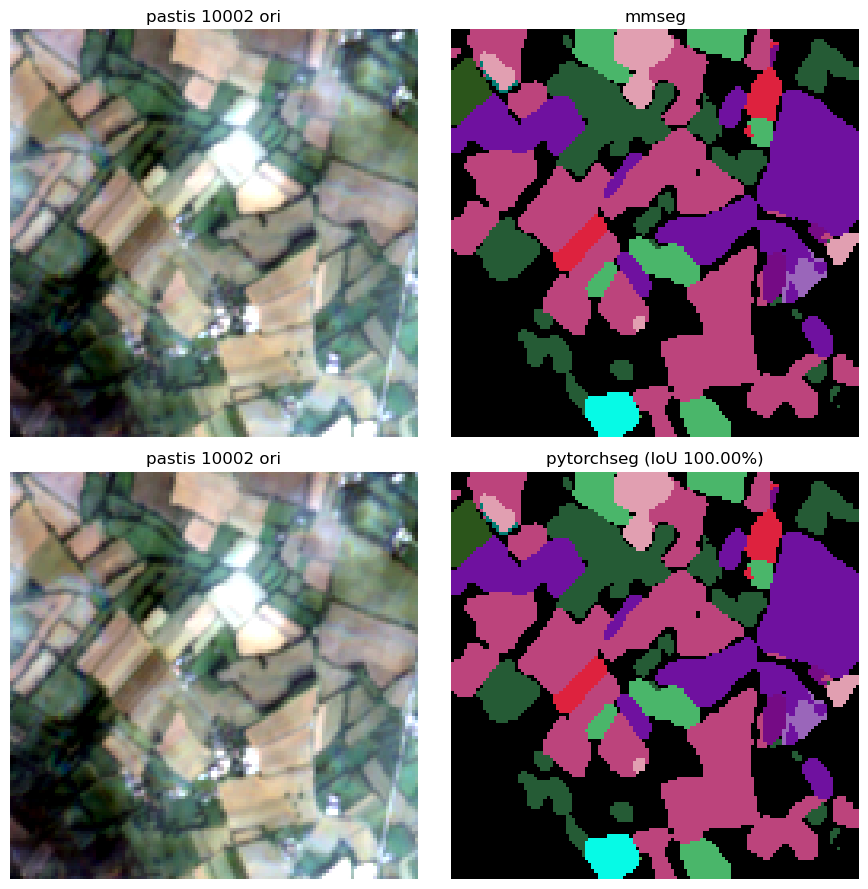

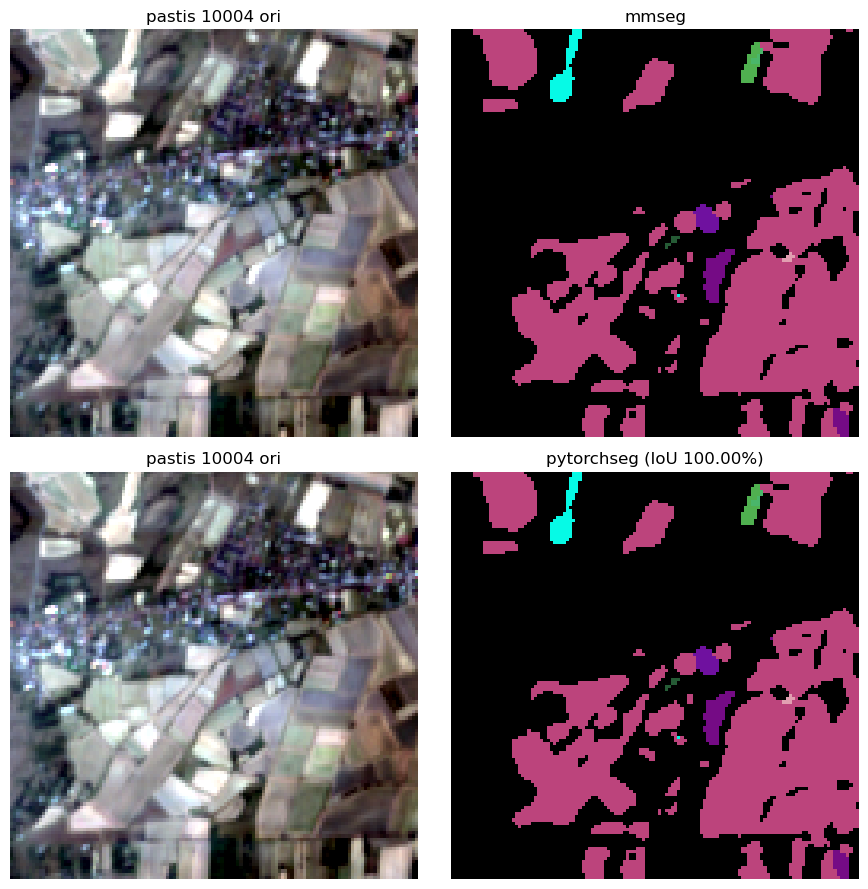

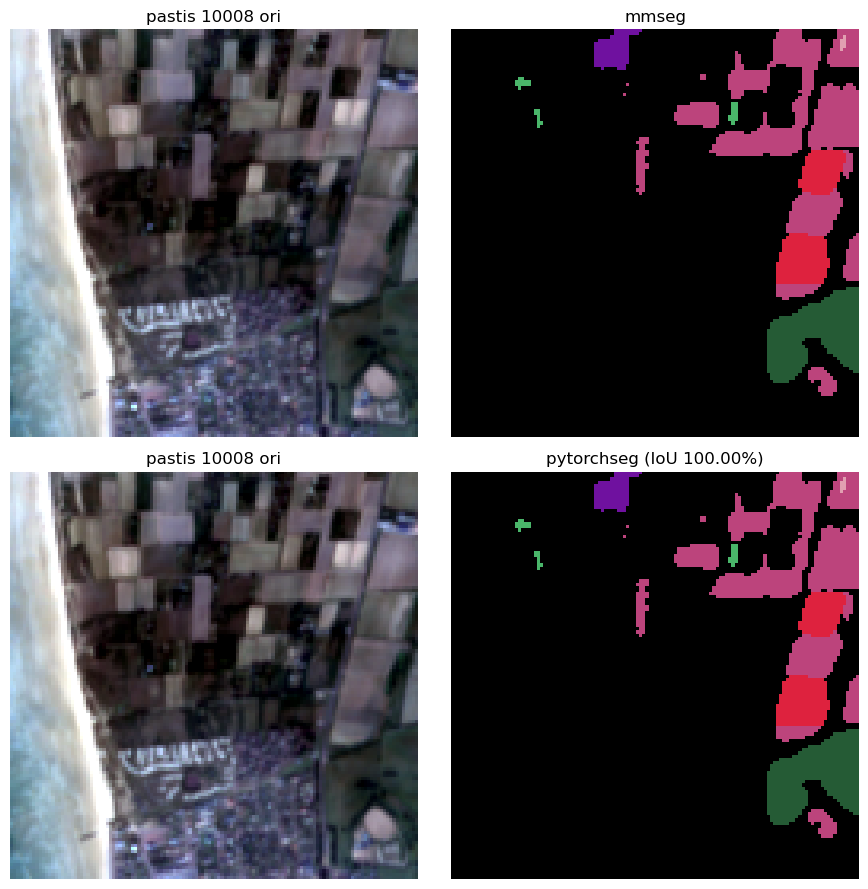

In [4]:
# 2. 取 val 样本 (PASTIS)
import json
_g = json.load(open(NETWORKS["pastis"]["data_root"] + "/metadata.geojson"))
_pids = [f["properties"]["ID_PATCH"] for f in _g["features"] if f["properties"]["Fold"]==4][:3]

_MEAN = np.array(NETWORKS["pastis"]["mean"], np.float32)
_STD  = np.array(NETWORKS["pastis"]["std"], np.float32)
def pastis_sample(pid):
    fr = np.load(f"{NETWORKS["pastis"]["data_root"]}/DATA_S2_M12/S2M_{pid}.npy").astype(np.float32)
    nm = (fr - _MEAN.reshape(1,-1,1,1)) / _STD.reshape(1,-1,1,1)
    T,C,H,W = nm.shape
    img = np.stack([cv2.resize(nm.reshape(T*C,H,W)[j],(256,256),interpolation=cv2.INTER_LINEAR) for j in range(T*C)])
    rgb = np.stack([fr[:,2].mean(0),fr[:,1].mean(0),fr[:,0].mean(0)],-1)
    for k in range(3):
        lo,hi=np.percentile(rgb[...,k],2),np.percentile(rgb[...,k],98)
        rgb[...,k]=np.clip((rgb[...,k]-lo)/(hi-lo+1e-6),0,1)
    return torch.from_numpy(np.ascontiguousarray(img)).float().unsqueeze(0).to(DEVICE), (rgb*255).astype(np.uint8)

# 3. 对比可视化 (2x2)
for pid in _pids:
    x, rgb = pastis_sample(pid)
    so = predict_mmseg(orig_pastis, x, 128, 128, 19)
    sn = predict_new(new_pastis, x, 128, 128, 19)
    agree = np.mean(so==sn)*100
    rgb_disp = cv2.resize(rgb,(128,128))
    fig,ax=plt.subplots(2,2,figsize=(9,9))
    ax[0,0].imshow(rgb_disp); ax[0,0].set_title(f"pastis {pid} ori"); ax[0,0].axis("off")
    ax[0,1].imshow(colorize(so,19)); ax[0,1].set_title("mmseg"); ax[0,1].axis("off")
    ax[1,0].imshow(rgb_disp); ax[1,0].set_title(f"pastis {pid} ori"); ax[1,0].axis("off")
    ax[1,1].imshow(colorize(sn,19)); ax[1,1].set_title(f"pytorchseg (IoU {agree:.2f}%)"); ax[1,1].axis("off")
    plt.tight_layout(); plt.show()
del orig_pastis; torch.cuda.empty_cache()

In [5]:
# ── agri 对比 ──
# 1. 原版 mmseg 模型 (agri 用 num_queries=50)
orig_agri = build_mmseg_original(
    AGRI_ROOT + "/configs/dinov3l_m2f_agri_v1.py",
    AGRI_ROOT + "/work_dirs/dinov3l_m2f_agri/best_mIoU_iter_60000.pth",
    AGRI_ROOT, num_queries=50)
print("[原版] agri 已加载")

embed dim 1024
interaction_indexes [5, 11, 17, 23]
patch_size 16
[原版] agri 已加载


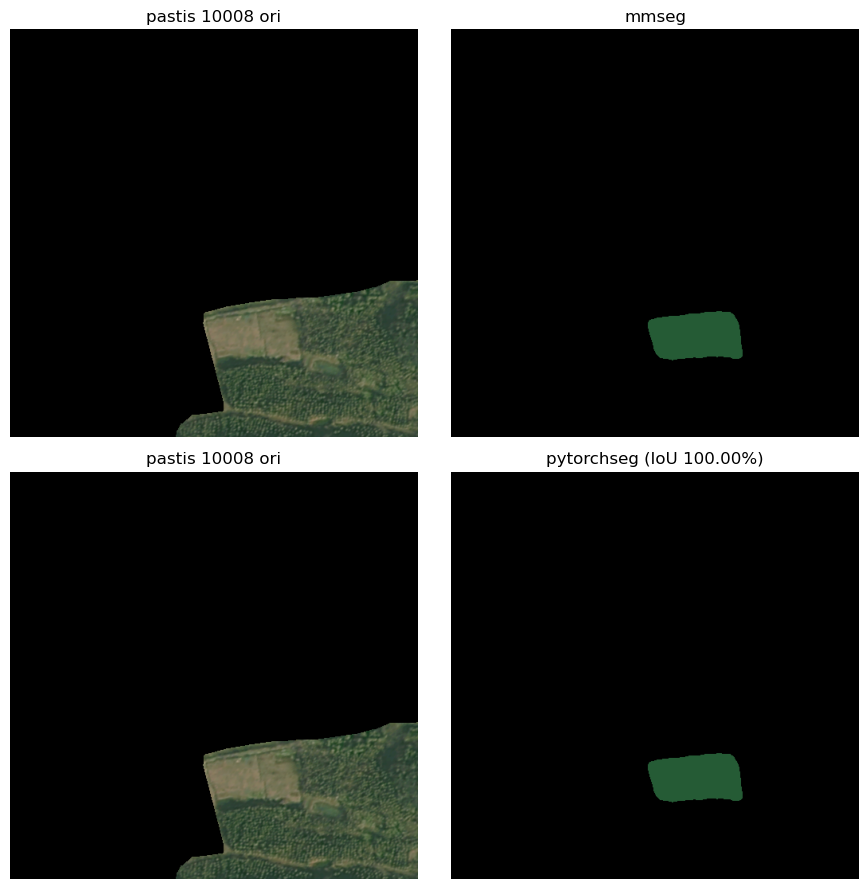

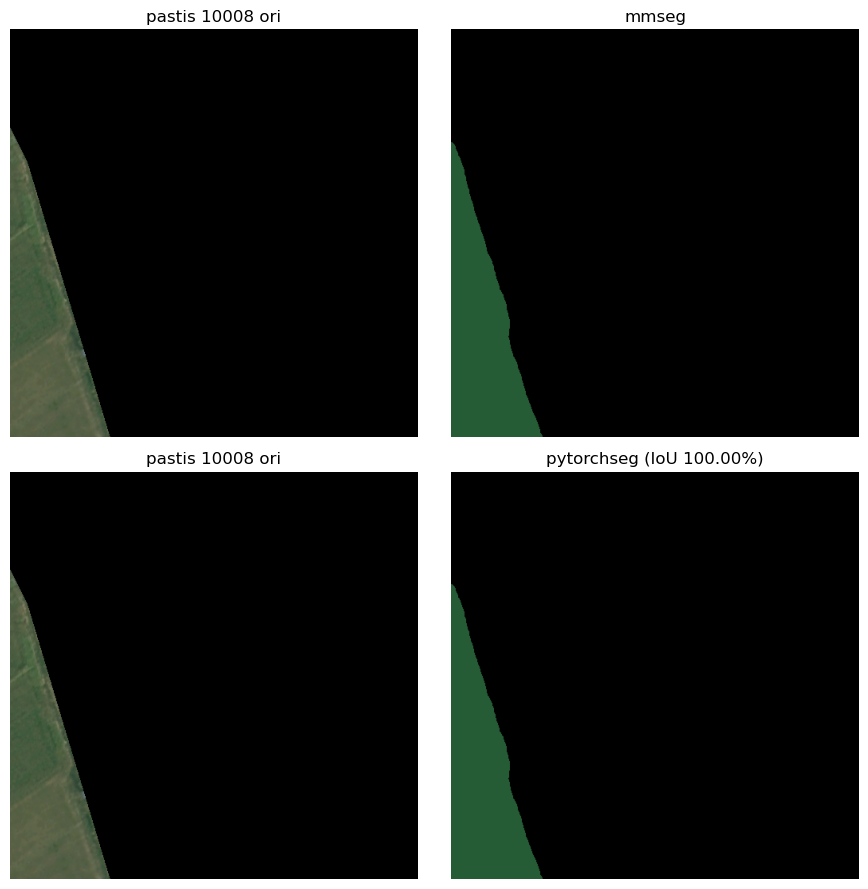

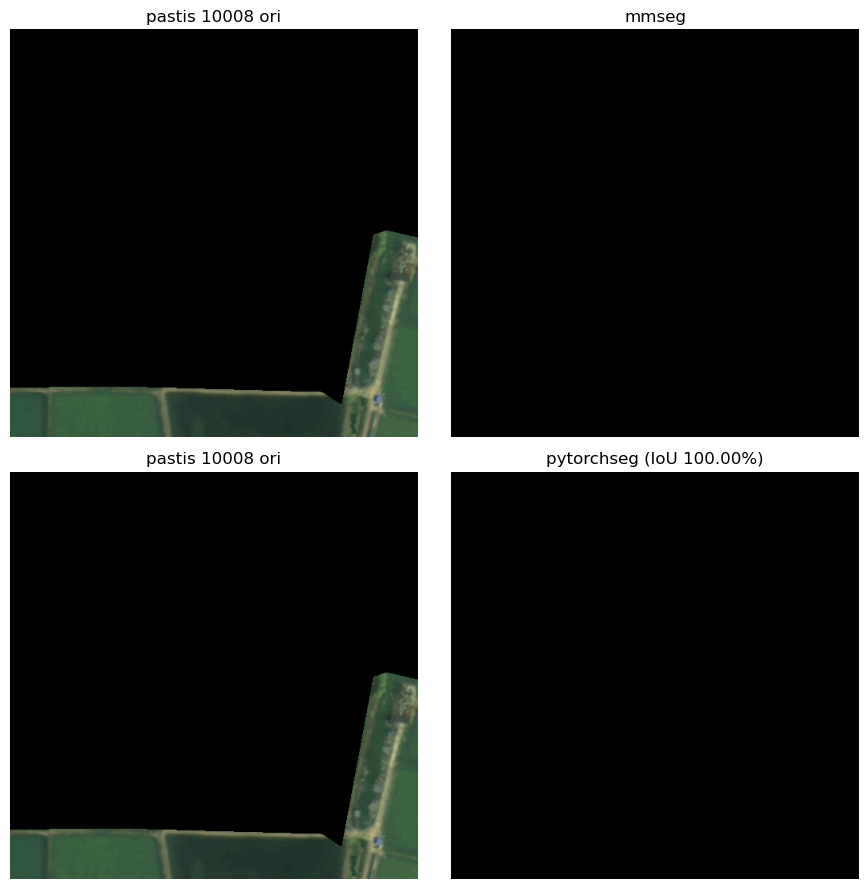

In [6]:
# 2. 取 valid 样本 (agri)
from pathlib import Path
_aroot = Path(NETWORKS["agri"]["data_root"])
_anames = [l.strip() for l in open(_aroot/"valid.txt")][:3]
_AMEAN = np.array(NETWORKS["agri"]["mean"], np.float32)
_ASTD  = np.array(NETWORKS["agri"]["std"], np.float32)
def agri_sample(nm):
    img = cv2.cvtColor(cv2.imread(str(_aroot/"img_dir"/f"{nm}.png")), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (512,512))
    x = torch.from_numpy(((img.astype(np.float32)-_AMEAN)/_ASTD).transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)
    return x, img

# 3. 对比可视化 (2x2)
for nm in _anames:
    x, rgb = agri_sample(nm)
    so = predict_mmseg(orig_agri, x, 512, 512, 2)
    sn = predict_new(new_agri, x, 512, 512, 2)
    agree = np.mean(so==sn)*100
    fig,ax=plt.subplots(2,2,figsize=(9,9))
    ax[0,0].imshow(rgb); ax[0,0].set_title(f"pastis {pid} ori"); ax[0,0].axis("off")
    ax[0,1].imshow(colorize(so,19)); ax[0,1].set_title("mmseg"); ax[0,1].axis("off")
    ax[1,0].imshow(rgb); ax[1,0].set_title(f"pastis {pid} ori"); ax[1,0].axis("off")
    ax[1,1].imshow(colorize(sn,19)); ax[1,1].set_title(f"pytorchseg (IoU {agree:.2f}%)"); ax[1,1].axis("off")
    plt.tight_layout(); plt.show()
del orig_agri; torch.cuda.empty_cache()